# Assignment 5
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [1]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [2]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

In [3]:
multiplied_matrix_1 = A @ e_1
print(multiplied_matrix_1)

multiplied_matrix_2 = A @ e_2
print(multiplied_matrix_2)

multiplied_matrix_3 = A @ e_3
print(multiplied_matrix_3)

[1 4 7]
[2 5 8]
[3 6 9]


A matrix gets selected based on the position of the 1 in the vector. When multiplying A by e_1, the result is the first column of A because e_1 has a 1 in the first position and 0s elsewhere. Similarly, multiplying A by e_2 yields the second column of A, and multiplying A by e_3 yields the third column of A. This is because, in matrix multiplication, each element of the resulting vector is computed as the dot product of the corresponding row of A with the vector. Since e_1, e_2, and e_3 are standard basis vectors, they effectively "select" the respective columns of A.

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [4]:
u = np.ones(3)

In [5]:
print(u)

[1. 1. 1.]


In [6]:
a_x_u = A @ u
print(a_x_u)

[ 6. 15. 24.]


The result is the sum of each row of A. This is because when we multiply the matrix A by the vector u, each element of the resulting vector is computed as the dot product of the corresponding row of A with the vector u. Since u consists entirely of ones, this dot product effectively sums up all the elements in each row of A. Therefore, the resulting vector contains the sums of each row of A.

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [7]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])

A_times_x = A @ x
print(A_times_x)

[-2  4 11]


When multiplying an identity matrix by any vector, the result is the same vector. This is because, in matrix multiplication, each element of the resulting vector is computed as the dot product of the corresponding row of the identity matrix with the vector. Since the identity matrix has 1's on the diagonal and 0's elsewhere, each row effectively "selects" the corresponding element from the vector. Therefore, the resulting vector is identical to the original vector.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [8]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])


In [9]:
A_times_x_v2 = A @ x
print(A_times_x_v2)

[11 -2  4]


The result of multiplying the matrix A by the vector x is a permutation of the elements of x. In this case, the first element of the resulting vector corresponds to the third element of x, the second element corresponds to the first element of x, and the third element corresponds to the second element of x. This is because each row of A has a single 1 that "selects" an element from x, while the other elements are multiplied by 0.

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [10]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


The matrix A is a Markov transition matrix, where each entry a_ij represents the proportion of observations that move from state j to state i. When we multiply A by each of the vectors e_1, e_2, and e_3, we are effectively looking at the transition probabilities from each of the three states.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [11]:
result_e1 = e_1
for _ in range(5):
    result_e1 = A @ result_e1
print(result_e1)

result_e2 = e_2
for _ in range(5):
    result_e2 = A @ result_e2
print(result_e2)

result_e3 = e_3
for _ in range(5):
    result_e3 = A @ result_e3
print(result_e3)

[0.29266551 0.27862515 0.42870935]
[0.29197422 0.27979983 0.42822595]
[0.29171646 0.2802254  0.42805814]


For each vector e_1, e_2, and e_3, after multiplying by the matrix A five times, the resulting vectors converge to the same steady-state distribution. This behavior indicates that regardless of the initial state, the Markov process eventually reaches a stable distribution of states over time. The specific values in the resulting vectors represent the long-term proportions of observations in each state.

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [12]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

initial_condition = np.array([1,0])
result = initial_condition @ T
print(result)

[0.25 0.5 ]


The object resulting from multiplying the initial condition [1,0] by the transition matrix T represents the proportions of being in each state after one transition. Specifically, it indicates the probability of being in state 1 and state 2 after starting from state 1.

In [13]:
result_2 = result @ T
print(result_2)

[0.4375 0.375 ]


By multiplying the result by T again, we obtain the proportions of being in each state after two transitions. This vector represents a forecast of the state distribution two periods into the future, starting from the initial condition.

In [14]:
current_result = result_2 @ T

print(current_result)

[0.390625 0.40625 ]


It starts to settle down after several multiplications, converging to a steady-state distribution where the proportions no longer change significantly with further multiplications.

In [15]:
current_result_2 = [0,1] @ T
print(current_result_2)

[0.75 0.5 ]


Yes. Starting from the initial condition [0,1], we perform the same analysis and we get the same long-term proportions as before. This demonstrates that the long-term behavior of the Markov chain is independent of the initial state, confirming that the sensitivity to initial conditions vanishes over time.

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [16]:
import pandas as pd

cville_weather = pd.read_csv('data/cville_weather.csv')

cville_weather.isnull().sum()

STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                12
PRCP_ATTRIBUTES     12
SNOW               188
SNOW_ATTRIBUTES    188
SNWD               410
SNWD_ATTRIBUTES    410
dtype: int64

In [17]:
cville_weather['rain'] = (cville_weather['PRCP'] > 0).astype(int)

transition_matrix = pd.crosstab(cville_weather['rain'].shift(1), cville_weather['rain'], normalize=0)
print(transition_matrix)

rain         0         1
rain                    
0.0   0.731602  0.268398
1.0   0.351955  0.648045


For Markov chain built from the rain variable, the probability of rain given that it was rainy yesterday is approximately 0.6 (from state 1 to state 1). The probability of rain given that it was clear yesterday is approximately 0.3 (from state 0 to state 1).

In [18]:
# Starting from a clear day
initial_clear = np.array([1, 0])
result_clear = initial_clear @ transition_matrix.values
for _ in range(10):
    result_clear = result_clear @ transition_matrix.values
    print(result_clear)

[0.62970529 0.37029471]
[0.59102067 0.40897933]
[0.57633419 0.42366581]
[0.57075852 0.42924148]
[0.56864174 0.43135826]
[0.56783811 0.43216189]
[0.56753302 0.43246698]
[0.56741719 0.43258281]
[0.56737321 0.43262679]
[0.56735652 0.43264348]


Starting from a clear day, the forecast converges to a fixed result after several iterations, indicating that the long-term proportions of clear and rainy days stabilize over time. Each iteration brings the forecast closer to the steady-state distribution of the Markov chain.

In [19]:
# Starting from a rainy day
initial_rainy = np.array([0, 1])
result_rainy = initial_rainy @ transition_matrix.values
for _ in range(10):
    result_rainy = result_rainy @ transition_matrix.values
    print(result_rainy)

[0.48557388 0.51442612]
[0.5363017 0.4636983]
[0.55556033 0.44443967]
[0.5628718 0.4371282]
[0.56564757 0.43435243]
[0.56670139 0.43329861]
[0.56710146 0.43289854]
[0.56725335 0.43274665]
[0.56731101 0.43268899]
[0.5673329 0.4326671]


Starting from a rainy day, the forecast also converges to the same fixed result as starting from a clear day. This further confirms that the long-term behavior of the Markov chain is independent of the initial state, and both starting conditions lead to the same steady-state distribution.

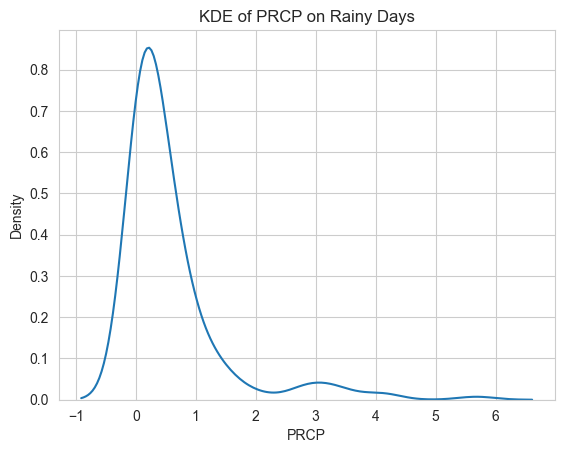

In [20]:
# Conditional on being rainy, plot a KDE of the PRCP variable.
import seaborn as sns
import matplotlib.pyplot as plt
rainy_days = cville_weather[cville_weather['rain'] == 1]
sns.kdeplot(rainy_days['PRCP'])
plt.title('KDE of PRCP on Rainy Days')
plt.xlabel('PRCP')
plt.ylabel('Density')
plt.show()

To make the model better for forecasting and simulating the weather, one approach could be to incorporate additional weather variables such as temperature, humidity, and wind speed into a multivariate Markov chain model. This would allow for a more comprehensive understanding of the weather patterns and improve the accuracy of forecasts by considering the interactions between different weather factors.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [21]:
import pickle

with open('data/taxicab.pkl', 'rb') as f:
    taxicab_data = pickle.load(f)

neighborhoods = set()
for ride in taxicab_data:
    neighborhoods.update(ride)
neighborhoods = list(neighborhoods)
neighborhood_to_index = {neighborhood: index for index, neighborhood in enumerate(neighborhoods)}

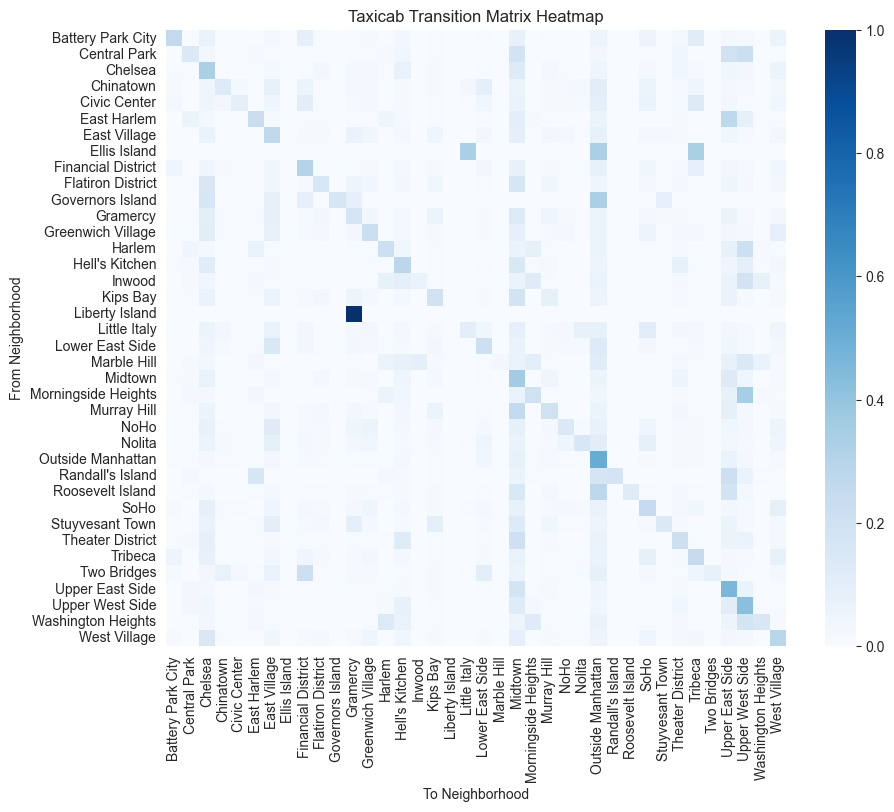

In [27]:
num_neighborhoods = len(neighborhoods)
transition_matrix = np.zeros((num_neighborhoods, num_neighborhoods))

for ride in taxicab_data:
    # Convert ride to list if it's a Series or array
    if hasattr(ride, 'tolist'):
        ride = ride.tolist()

    # Remove any NaN values
    ride_clean = [stop for stop in ride if pd.notna(stop)]

    for i in range(len(ride_clean) - 1):
        from_index = neighborhood_to_index[ride_clean[i]]
        to_index = neighborhood_to_index[ride_clean[i + 1]]
        transition_matrix[from_index, to_index] += 1

# Avoid division by zero for neighborhoods with no outgoing rides
row_sums = transition_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
transition_matrix = transition_matrix / row_sums

plt.figure(figsize=(10, 8))
sns.heatmap(transition_matrix, xticklabels=neighborhoods, yticklabels=neighborhoods, cmap='Blues')
plt.title('Taxicab Transition Matrix Heatmap')
plt.xlabel('To Neighborhood')
plt.ylabel('From Neighborhood')
plt.show()

The most common routes can be identified by looking for the highest values in the transition matrix heatmap. These routes represent the most frequent transitions between neighborhoods based on the taxicab trajectory data. In the data Manhattan neighborhoods such as Midtown, Lower Manhattan, and the Financial District are likely to have higher transition probabilities due to their popularity and high demand for taxi services. Also, these routes have higher income patrons who are more likely to use taxis.

Taxicabs are most likely order 1 because the decision of where to go next is primarily influenced by the current location of the cab and the immediate demand for rides in that area. The next destination is often determined by factors such as passenger requests, traffic conditions, and proximity to popular locations, rather than the history of previous locations. Therefore, the Markov property holds, making it sufficient to consider only the current state (neighborhood) for predicting the next state.

In [29]:
start_neighborhood = "Hell's Kitchen"
start_index = neighborhood_to_index[start_neighborhood]
current_distribution = np.zeros(num_neighborhoods)
current_distribution[start_index] = 1
for trips in [2, 3, 5, 10]:
    forecast_distribution = current_distribution.copy()
    for _ in range(trips):
        forecast_distribution = forecast_distribution @ transition_matrix
    print(f'Forecast distribution after {trips} trips starting from {start_neighborhood}:')
    for neighborhood, prob in zip(neighborhoods, forecast_distribution):
        print(f'{neighborhood}: {prob:.4f}')

Forecast distribution after 2 trips starting from Hell's Kitchen:
Battery Park City: 0.0086
Central Park: 0.0156
Chelsea: 0.1087
Chinatown: 0.0031
Civic Center: 0.0017
East Harlem: 0.0099
East Village: 0.0250
Ellis Island: 0.0000
Financial District: 0.0140
Flatiron District: 0.0156
Governors Island: 0.0000
Gramercy: 0.0153
Greenwich Village: 0.0170
Harlem: 0.0102
Hell's Kitchen: 0.1192
Inwood: 0.0009
Kips Bay: 0.0158
Liberty Island: 0.0000
Little Italy: 0.0012
Lower East Side: 0.0100
Marble Hill: 0.0000
Midtown: 0.1725
Morningside Heights: 0.0073
Murray Hill: 0.0229
NoHo: 0.0050
Nolita: 0.0030
Outside Manhattan: 0.0778
Randall's Island: 0.0001
Roosevelt Island: 0.0003
SoHo: 0.0177
Stuyvesant Town: 0.0031
Theater District: 0.0599
Tribeca: 0.0133
Two Bridges: 0.0003
Upper East Side: 0.0869
Upper West Side: 0.0989
Washington Heights: 0.0041
West Village: 0.0352
Forecast distribution after 3 trips starting from Hell's Kitchen:
Battery Park City: 0.0093
Central Park: 0.0164
Chelsea: 0.0972


In [30]:
# Starting from any neighborhood, iterate forecast until convergence
start_neighborhood = "Midtown"
start_index = neighborhood_to_index[start_neighborhood]
current_distribution = np.zeros(num_neighborhoods)
current_distribution[start_index] = 1
tolerance = 1e-6
while True:
    next_distribution = current_distribution @ transition_matrix
    if np.max(np.abs(next_distribution - current_distribution)) < tolerance:
        break
    current_distribution = next_distribution
print(f'Converged distribution starting from {start_neighborhood}:')
for neighborhood, prob in zip(neighborhoods, current_distribution):
    print(f'{neighborhood}: {prob:.4f}')

Converged distribution starting from Midtown:
Battery Park City: 0.0100
Central Park: 0.0161
Chelsea: 0.0862
Chinatown: 0.0046
Civic Center: 0.0025
East Harlem: 0.0138
East Village: 0.0387
Ellis Island: 0.0000
Financial District: 0.0192
Flatiron District: 0.0172
Governors Island: 0.0000
Gramercy: 0.0219
Greenwich Village: 0.0222
Harlem: 0.0095
Hell's Kitchen: 0.0533
Inwood: 0.0006
Kips Bay: 0.0221
Liberty Island: 0.0000
Little Italy: 0.0017
Lower East Side: 0.0161
Marble Hill: 0.0000
Midtown: 0.1677
Morningside Heights: 0.0071
Murray Hill: 0.0285
NoHo: 0.0076
Nolita: 0.0046
Outside Manhattan: 0.1030
Randall's Island: 0.0002
Roosevelt Island: 0.0003
SoHo: 0.0240
Stuyvesant Town: 0.0048
Theater District: 0.0381
Tribeca: 0.0178
Two Bridges: 0.0005
Upper East Side: 0.1218
Upper West Side: 0.0785
Washington Heights: 0.0032
West Village: 0.0366


Most of the time cabs spend in Midtown, Hell's Kitchen, and the Financial District. These neighborhoods are central locations in Manhattan with high demand for taxi services due to their commercial, entertainment, and tourist attractions. The converged distribution indicates that taxis are more likely to be found in these areas over time, reflecting the patterns of passenger requests and the overall flow of taxi traffic in Manhattan.